# A4 · Point-in-Time Data: Timestamps, Time Zones and the Market Close

*Sentiment & Alternative Data track*

The most common way to fool yourself with alternative data is a timestamp mistake. This notebook builds a news dataset that has, by construction, *zero* predictive power, then shows how a natural-looking alignment makes it appear to predict the market almost perfectly.

## 1. Motivation

A student downloads a year of news headlines, scores their sentiment (A2), averages the scores per day, and correlates them with the market's return that day. The correlation is strong. Good news days are up days. They build a strategy: "go long when today's news is positive". The backtest shows a Sharpe ratio above 5. Unfortunately, most of those headlines were written *because* the market moved: "Stocks rally as inflation cools" is published after the rally. The headline didn't predict the move. The move produced the headline. The question that matters is: **when could I have read this, and what could I still have traded at that point?**

## 2. Intuition

Every piece of data has two times attached:

- **Event time:** when the thing it describes happened.
- **Availability time:** when *you* could first have seen it.

A backtest must only use data at its availability time. For daily strategies, the key boundary is the **market close** (4:00 pm New York time for US stocks). Our returns are close-to-close. So:

- A headline published *before* the close on day $t$ can drive a trade at day $t$'s close, which earns day $t+1$'s return.
- A headline published *after* the close on day $t$ can only be traded at the close of day $t+1$, which earns day $t+2$'s return. (Or at the next morning's open, if you have opening prices.)

Two practical traps make this hard:

1. **Date-only stamps.** Many datasets give a date but no time. You don't know whether an item came before or after the close, so you must assume the worst: after.
2. **Time zones.** A timestamp of "2024-03-05 02:00" could be UTC (9 pm the previous evening in New York) or New York time. Mixing them up shifts data by several hours, and an item published just *after* the close can appear to have arrived *before* it. That matters most for the most valuable news: companies usually release earnings just after the 4 pm close.

## 3. The math

Let $\tau_j$ be the availability time of news item $j$ (in New York time) and $s_j$ its sentiment score. Let $c_t$ be the close of trading day $t$. The set of items **known at the close of day $t$** is
$$
\mathcal I_t = \{\, j : \tau_j \le c_t \,\}.
$$
A tradable daily signal must only use items in $\mathcal I_t$ that are new since the previous close:
$$
S_t = \operatorname{mean}\{\, s_j : c_{t-1} < \tau_j \le c_t \,\},
$$
and it can only be compared with *later* returns, $R_{t+1}, R_{t+2}, \dots$

The tempting but wrong version groups items by the **calendar date** of $\tau_j$ and compares them with the **same day's** return $R_t$. Any item written *during or after* day $t$'s session in reaction to $R_t$ then creates a correlation between $S_t$ and $R_t$, with no predictive content at all.

In pandas, `merge_asof` performs the "latest close at or after this timestamp" lookup directly: it assigns each news item to the first trading-day close at or after its timestamp.

## 4. Code it

### 4.1 Setup: real returns, simulated reactive news

The returns are real SPY returns. The news items are **simulated**, of two kinds:

- **Reactive articles** (20 a day, at random times): each one reacts to the market move that happened *before* it was written, plus noise. They contain no information about the future.
- **After-close announcements** (2 a day, between 4:00 and 5:00 pm): like earnings releases, they carry real news that *moves the next day's market*. Their sentiment is related to the next day's return.

With close-to-close prices, a correct backtest can't profit from either kind: the reactive ones are stale, and the announcements arrive after the last close we could trade at before the move.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

spy = prices["SPY"].pct_change().loc["2018":].dropna()
days = spy.index
NY = "America/New_York"
pd.set_option("display.width", 140)
closes = pd.DatetimeIndex([d + pd.Timedelta(hours=16) for d in days]).tz_localize(NY)   # c_t: 4 pm New York
opens = closes - pd.Timedelta(hours=6, minutes=30)                                       # 9:30 am

rng = np.random.default_rng(0)
items = []
for k in range(1, len(days)):
    prev_close, this_open, this_close = closes[k - 1], opens[k], closes[k]
    r_prev, r_today = spy.iloc[k - 1], spy.iloc[k]
    for _ in range(20):
        # Random publication time between the previous close and this close (about 24h, longer over weekends)
        t = prev_close + (this_close - prev_close) * rng.random()
        # What has the writer seen? Before the open: yesterday's move. During the session: part of today's.
        if t < this_open:
            seen = r_prev
        else:
            fraction = (t - this_open) / (this_close - this_open)
            seen = r_today * fraction
        sentiment = np.tanh(seen / 0.01 + rng.normal(0, 1.0))      # reacts to the past, plus noise
        items.append((t, sentiment))
    if k + 1 < len(days):
        for _ in range(2):
            # After-close announcement on day k: news that drives the NEXT day's return
            t = this_close + pd.Timedelta(minutes=1 + 59 * rng.random())
            sentiment = np.tanh(spy.iloc[k + 1] / 0.01 + rng.normal(0, 1.0))
            items.append((t, sentiment))

news = pd.DataFrame(items, columns=["published_ny", "sentiment"]).sort_values("published_ny")
news["published_ny"] = news["published_ny"].dt.tz_convert("UTC").dt.floor("s").dt.tz_convert(NY)  # whole seconds
news["published_utc"] = news["published_ny"].dt.tz_convert("UTC")   # how many vendors store it
print(f"{len(news):,} simulated news items")
news.head()

48,332 simulated news items


,published_ny,sentiment,published_utc
10,2018-01-02 16:40:46-05:00,0.969397,2018-01-02 21:40:46+00:00
1,2018-01-02 16:59:00-05:00,0.675412,2018-01-02 21:59:00+00:00
16,2018-01-02 19:14:32-05:00,0.850117,2018-01-03 00:14:32+00:00
9,2018-01-02 23:11:35-05:00,0.942306,2018-01-03 04:11:35+00:00
18,2018-01-03 03:39:36-05:00,0.527096,2018-01-03 08:39:36+00:00


### 4.2 The tempting (wrong) alignment: same calendar date, same day's return

In [2]:
news["date_naive"] = news["published_ny"].dt.tz_localize(None).dt.normalize()   # calendar date only
daily_naive = news.groupby("date_naive")["sentiment"].mean().reindex(days)

def evaluate(signal, label):
    """Correlation with the return it is paired with, and the Sharpe of trading its sign."""
    df = pd.concat([signal.rename("s"), spy.rename("r")], axis=1).dropna()
    pnl = np.sign(df["s"]) * df["r"]
    return {"alignment": label, "corr": df["s"].corr(df["r"]),
            "Sharpe of sign(signal) x return": np.sqrt(252) * pnl.mean() / pnl.std()}

results = [evaluate(daily_naive, "Calendar date, same-day return (wrong)")]
pd.DataFrame(results).round(2)

,alignment,corr,Sharpe of sign(signal) x return
0,"Calendar date, same-day return (wrong)",0.57,7.71


A correlation of 0.57 and a Sharpe ratio near 8, from news that by construction contains *no* usable information about the future. Grouping by calendar date puts articles written during and after day $t$'s session, in reaction to day $t$'s move, into day $t$'s bucket. Pairing that bucket with day $t$'s return measures how well journalists describe the market, not how well news predicts it.

### 4.3 The correct alignment: available at which close?

`merge_asof` with `direction="forward"` assigns each item to the first close *at or after* its publication time. That close is the earliest moment we could trade on it. The signal formed at close $c_t$ then earns the return of day $t+1$.

In [3]:
close_table = pd.DataFrame({"close_time": closes, "trade_day": days})

aligned = pd.merge_asof(news.sort_values("published_ny"), close_table,
                        left_on="published_ny", right_on="close_time", direction="forward")
signal_at_close = aligned.groupby("trade_day")["sentiment"].mean().reindex(days)   # S_t, known at c_t

correct = signal_at_close.shift(1)          # S_t is paired with the return of day t+1
results.append(evaluate(correct, "Known at close t, return of day t+1 (correct)"))
pd.DataFrame(results).round(2)

,alignment,corr,Sharpe of sign(signal) x return
0,"Calendar date, same-day return (wrong)",0.57,7.71
1,"Known at close t, return of day t+1 (correct)",-0.01,-0.10


Aligned by availability, the correlation is zero and the strategy's Sharpe ratio is about zero. This is the true answer for this dataset: everything in it was either stale by the time we could trade, or arrived after the last close before the move it predicts.

### 4.4 The time-zone trap

Suppose a vendor stores timestamps as plain New York clock times with no time-zone label, and someone assumes they are UTC and converts them to New York time. Every item now looks **4–5 hours earlier than it really was**. A 4:30 pm earnings release appears to have arrived at about 11:30 am, before the close. The backtest then "trades" on it at the 4 pm close and earns the next day's reaction.

Items made to look earlier by 4 to 5 hours


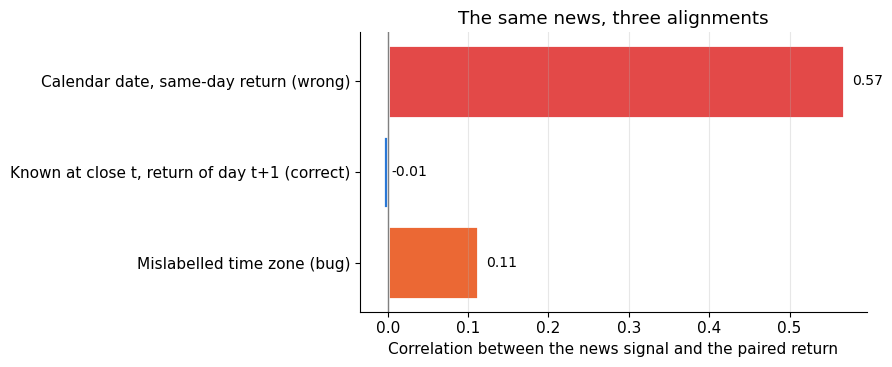

,alignment,corr,Sharpe of sign(signal) x return
0,"Calendar date, same-day return (wrong)",0.57,7.71
1,"Known at close t, return of day t+1 (correct)",-0.01,-0.10
2,Mislabelled time zone (bug),0.11,1.20


In [4]:
# The bug: plain New York clock readings wrongly labelled as UTC, then converted to New York time
naive_clock = news["published_ny"].dt.tz_localize(None)
news["mislabelled"] = naive_clock.dt.tz_localize("UTC").dt.tz_convert(NY)
shift_h = (news["published_ny"] - news["mislabelled"]).dt.total_seconds() / 3600
print(f"Items made to look earlier by {shift_h.min():.0f} to {shift_h.max():.0f} hours")

bug = pd.merge_asof(news.sort_values("mislabelled"), close_table,
                    left_on="mislabelled", right_on="close_time", direction="forward")
signal_bug = bug.groupby("trade_day")["sentiment"].mean().reindex(days).shift(1)   # same pairing as 4.3
results.append(evaluate(signal_bug, "Mislabelled time zone (bug)"))

res = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(9, 3.8))
colors = [COLORS[7], COLORS[0], COLORS[1]]
ax.barh(res["alignment"], res["corr"], color=colors, edgecolor="white", linewidth=2)
for i, v in enumerate(res["corr"]):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=10)
ax.axvline(0, color="grey", linewidth=1)
ax.set_xlabel("Correlation between the news signal and the paired return")
ax.set_title("The same news, three alignments")
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()
res.round(2)

The time-zone bug is the most dangerous of the three, precisely because its result looks *believable*. A Sharpe ratio of 8 makes everyone suspicious. A correlation of 0.11 and a Sharpe ratio of 1.2 look like a good, publishable signal. Yet it comes entirely from the after-close announcements being moved a few hours earlier, across the 4 pm boundary. In real data, earnings releases, guidance updates and many company press releases cluster just after the close, so this exact bug inflates many real backtests.

With open-to-close or intraday prices you *could* legitimately trade on after-close news at the next open. That is a different strategy, with different costs, and it needs exact timestamps.

## 5. Takeaways and where it breaks

- **Always ask "when could I have seen this?"**, not "what date is this about?". Store the *availability* timestamp, with its time zone, for every data point.
- **The market close is the boundary.** With close-to-close returns, anything published after the close can only affect the day after next.
- **Use `merge_asof`** (with timezone-aware timestamps) to assign each item to the first moment you could trade on it.
- **Check your result against reactive news.** A strong correlation between same-day sentiment and same-day returns is the expected result even with zero predictive power. It is not evidence of a signal.
- **Where it breaks:** real feeds have extra problems. Stories get updated or re-stamped, vendors backfill history, and the "publication time" may be when the vendor *received* the story, not when the public saw it. Check a sample by hand.

**What you could build:** a point-in-time data loader for the team's chosen source: it stores raw items with their availability timestamps in UTC, converts them to exchange time, and produces daily signals aligned to the close, with tests that fail if any item is used before its timestamp.